# Mobile App Market Analysis: 
What Makes an App Profitable? 

The mobile app market is dominated by free, ad-supported apps, meaning revenue is driven primarily by the number of users an app attracts rather than its price. For developers deciding what kind of app to build next, understanding which app categories and profiles tend to draw the largest audiences is a valuable, data-driven starting point.

This project analyzes two datasets sourced from Kaggle: a collection of Android apps from the Google Play Store, and a collection of iOS apps from the Apple App Store. By exploring genre popularity, user ratings, and installs across both platforms, the goal is to identify patterns that distinguish successful, high-engagement apps — and to see whether those patterns hold consistently across both app ecosystems or differ by platform.

In [1]:
# Import the CSV reader
from csv import reader 
# Load the App Store dataset
opened_file = open('AppleStore.csv')
read_file = reader(opened_file)
apple_store = list(read_file) # data with no alterations including header 
apple_header = apple_store[0] # header row of data 
apple_data = apple_store[1:] # data without header 

# Load the Google Play dataset
opened_file2 = open('googleplaystore.csv')
read_file2 = reader(opened_file2)
googleplaystore = list(read_file2) # data with no alterations including header 
google_header = googleplaystore[0]  # header row of data 
google_data = googleplaystore[1:] # data without header 


# Print a slice of rows, optionally with the row and column count
def explore_data(dataset, start, end, rows_and_columns=False):
    dataset_slice = dataset[start:end]
    
    for row in dataset_slice:
        print(row)  # Print the row 
        print('\n')  # Blank line between rows
    
    # Optionally print the dataset size
    if rows_and_columns:
        print('Number of rows:', len(dataset))
        print('Number of columns:', len(dataset[0]))


In [2]:
# Preview the first 3 App Store rows
print(explore_data(apple_data, 0 , 3, rows_and_columns=True))

['284882215', 'Facebook', '389879808', 'USD', '0.0', '2974676', '212', '3.5', '3.5', '95.0', '4+', 'Social Networking', '37', '1', '29', '1']


['389801252', 'Instagram', '113954816', 'USD', '0.0', '2161558', '1289', '4.5', '4.0', '10.23', '12+', 'Photo & Video', '37', '0', '29', '1']


['529479190', 'Clash of Clans', '116476928', 'USD', '0.0', '2130805', '579', '4.5', '4.5', '9.24.12', '9+', 'Games', '38', '5', '18', '1']


Number of rows: 7197
Number of columns: 16
None


In [3]:
# Preview the first 3 Google Play rows
print(explore_data(google_data, 0, 3, rows_and_columns=True))

['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', 'January 7, 2018', '1.0.0', '4.0.3 and up']


['Coloring book moana', 'ART_AND_DESIGN', '3.9', '967', '14M', '500,000+', 'Free', '0', 'Everyone', 'Art & Design;Pretend Play', 'January 15, 2018', '2.0.0', '4.0.3 and up']


['U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'ART_AND_DESIGN', '4.7', '87510', '8.7M', '5,000,000+', 'Free', '0', 'Everyone', 'Art & Design', 'August 1, 2018', '1.2.4', '4.0.3 and up']


Number of rows: 10841
Number of columns: 13
None


In [4]:
# Column names for both datasets
print("Apple Store columns:")
print(apple_header) # App Store column names

print("\nGoogle play columns:")
print(google_header) # Google Play column names

Apple Store columns:
['id', 'track_name', 'size_bytes', 'currency', 'price', 'rating_count_tot', 'rating_count_ver', 'user_rating', 'user_rating_ver', 'ver', 'cont_rating', 'prime_genre', 'sup_devices.num', 'ipadSc_urls.num', 'lang.num', 'vpp_lic']

Google play columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


# Apple Store Columns:

id | trackname | size_bytes | currency | price | rating_count_tot | rating_count_ver | user_Rating | user_Rating_ver | ver | count_rating | prime_genre | sup_devices.num | ipadSc_urls.num | lang.num | vpp_lic 
| ---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | ---: |  





# Google Play Store Columns:

App | Category | Rating | Reviews | Size | Installs | Type | Price | Content Rating | Genres | Last Updated | Current Ver | Android Ver|
--- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |

Link for further analysis of Apple Store Dataset: [Apple Store Dataset](https://www.kaggle.com/datasets/ramamet4/app-store-apple-data-set-10k-apps)

Link for further analysis of Googleplaystore Dataset: [Google Play Store](https://www.kaggle.com/datasets/lava18/google-play-store-apps)

In [5]:
# Find rows with a rating above 5 or a rating that is not a number
for i, row in enumerate(googleplaystore):
    try:
        rating = float(row[2])
        if rating > 5:
            print(f"row {i} has an invalid rating: {rating}")
            print(row)
    except:
        print(f"Row {i} has error converting rating")
        print(row)

Row 0 has error converting rating
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
row 10473 has an invalid rating: 19.0
['Life Made WI-Fi Touchscreen Photo Frame', '1.9', '19', '3.0M', '1,000+', 'Free', '0', 'Everyone', '', 'February 11, 2018', '1.0.19', '4.0 and up']


In [6]:
# Remove the row with the invalid rating (run once: re-running deletes another row)
del google_data[10472]

In [7]:
# Total rows in the raw Google Play data (including header)
len(googleplaystore)

10842

In [8]:
# Google Play: sort app names into unique and duplicate lists
duplicate_apps = []
unique_apps = []

for app in google_data:
    name = app[0]
    if name in unique_apps:
        duplicate_apps.append(name)
    else:
        unique_apps.append(name)
print('Number of duplicate apps in the Google Play Dataset:', len(duplicate_apps))
print('\n')
print('All duplicate apps', duplicate_apps[:15])

# Print every Google Play row whose name is duplicated
for i, app in enumerate(google_data):
    name = app[0]
    if name in duplicate_apps:
        print(f"Row {i}: {app}")
        print('\n')

# App Store: same duplicate check
duplicate_apps_apple = []
unique_apps_apple = []

for app in apple_data:
    name = app[1]
    if name in unique_apps_apple:
        duplicate_apps_apple.append(name)
    else:
        unique_apps_apple.append(name)
print('Number of duplicate apps in Apple Store Dataset:', len(duplicate_apps_apple))
print('\n')
print('All duplicate apps', duplicate_apps_apple[:15])

# Print every App Store row whose name is duplicated
for i, app in enumerate(apple_data):
    name = app[1]
    if name in duplicate_apps_apple:
        print(f"Row {i}: {app}")
        print('\n')


Number of duplicate apps in the Google Play Dataset: 1181


All duplicate apps ['Quick PDF Scanner + OCR FREE', 'Box', 'Google My Business', 'ZOOM Cloud Meetings', 'join.me - Simple Meetings', 'Box', 'Zenefits', 'Google Ads', 'Google My Business', 'Slack', 'FreshBooks Classic', 'Insightly CRM', 'QuickBooks Accounting: Invoicing & Expenses', 'HipChat - Chat Built for Teams', 'Xero Accounting Software']
Row 1: ['Coloring book moana', 'ART_AND_DESIGN', '3.9', '967', '14M', '500,000+', 'Free', '0', 'Everyone', 'Art & Design;Pretend Play', 'January 15, 2018', '2.0.0', '4.0.3 and up']


Row 23: ['Mcqueen Coloring pages', 'ART_AND_DESIGN', 'NaN', '61', '7.0M', '100,000+', 'Free', '0', 'Everyone', 'Art & Design;Action & Adventure', 'March 7, 2018', '1.0.0', '4.1 and up']


Row 36: ['UNICORN - Color By Number & Pixel Art Coloring', 'ART_AND_DESIGN', '4.7', '8145', '24M', '500,000+', 'Free', '0', 'Everyone', 'Art & Design;Creativity', 'August 2, 2018', '1.0.9', '4.4 and up']


Row 42: ['Textgram

# Duplicate Datasets
The Google Play dataset has 1181 duplicates. 

To find duplicates, I created two lists: unique_apps and duplicate_apps. I then looped through the dataset and used an if statement to check each app's name: if the name wasn't already in unique_apps, it was added there; if it was already present, it was added to duplicate_apps instead.


I then wrote a second loop to locate the exact rows containing duplicate apps. Using enumerate, this loop goes through each row in google_data while keeping track of its row number (i). For each row, it extracts the app name (the first element) and checks whether that name appears in the duplicate_apps list. If it does, the loop prints the row number and the full row of data. A print('\n') is added after each result to separate entries, making the output easier to read.

The removal process isn't random — it's deliberate. For each set of duplicate rows, only the entry with the highest number of user reviews is kept, and the rest are deleted. The reasoning is that a higher review count likely reflects more recent (and therefore more reliable) data.

The App Store check (by app name, `track_name`) finds 2 names that appear twice: Mannequin Challenge and VR Roller Coaster. These rows are left in: 2 rows out of 7,197 are unlikely to change any genre result.

In [9]:
# Highest review count for each app name
reviews_max = {}

# Store a review count for every app name
for app in google_data:
    name = app[0]
    n_reviews = float(app[3])
    
    if name in unique_apps:
        reviews_max[name] = n_reviews

# Raise the stored count if a duplicate row has more reviews
for app in google_data:
    name = app[0]
    if name in duplicate_apps:
        n_reviews = float(app[3])
        if name in reviews_max and reviews_max[name] < n_reviews:
            reviews_max[name] = n_reviews

# Rebuild the dataset with one row per app (the highest-review row)
android_clean = []
already_added = []

for app in google_data:
    name = app[0]
    n_reviews = float(app[3])
    
    if (reviews_max[name] == n_reviews) and (name not in already_added):
        android_clean.append(app)
        already_added.append(name)

# Check: both counts should match
print(len(android_clean))
print(len(reviews_max))    
        
        
        


9659
9659


### Removing duplicate entries

To remove the duplicate rows, I used two steps.

**1. Building a dictionary of the highest review count per app**

I created an empty dictionary, `reviews_max`, then looped through the entire Google Play dataset. For each row, I checked whether the app's name was already a key in the dictionary:

- If it was, and the current row's review count was higher than the value already stored, I updated the dictionary with the higher number.
- If it wasn't, I added it as a new entry with its review count.

This left `reviews_max` with exactly one entry per unique app name, mapping each app to the highest number of reviews found across all its duplicate rows.

**2. Rebuilding the dataset with only one row per app**

Using `reviews_max`, I looped through the dataset again and built a new list, `android_clean`, along with a helper list, `already_added`, to track which app names had already been included.

For each row, I only added it to `android_clean` if both conditions were true:

- its review count matched the maximum recorded for that app in `reviews_max`, and
- its name wasn't already in `already_added`.

The second condition was necessary because some apps had duplicate rows with the *same* (tied) maximum review count — without checking `already_added`, both tied rows would have passed the first condition and been added, letting a duplicate slip back into the cleaned dataset.

After running both loops, `len(reviews_max)` and `len(android_clean)` both returned 9,659, confirming the dataset was fully de-duplicated with no apps lost or double-counted.

In [10]:
# Return True if every character is plain ASCII or a common symbol or emoji
def non_english_detector(character):
    
    # Check each character in the name
    for char in character:
       # Get the character's Unicode code point
        code = ord(char)
        if not (
            code <= 127 or                    # English letters, digits, basic punctuation
            8192 <= code <= 8303 or           # general punctuation
            8352 <= code <= 8399 or           # currency symbols
            8448 <= code <= 8527 or           # letterlike symbols
            8592 <= code <= 8703 or           # arrows
            8704 <= code <= 8959 or           # math operators
            9472 <= code <= 10175 or          # box drawing, shapes, misc symbols
            127462 <= code <= 127487 or       # flag letters
            127744 <= code <= 129791 or       # main emoji blocks
            code in (8205, 65039)
        ):
            # Reject on the first character outside the allowed ranges
            return False
     # No disallowed characters found
    return True
      
# Google Play rows with English names
english_apps = []

# Keep rows whose app name passes the check
for row in  android_clean: 
   # App name column
    app_name = row[0]
    if non_english_detector(app_name) == True:
        # Keep the whole row
        english_apps.append(row)
      
# App Store rows with English names
english_apps_apple = []

# Keep rows whose app name passes the check
for row in  apple_data: 
   # App name column
    app_name = row[1]
    if non_english_detector(app_name) == True:
        # Keep the whole row
        english_apps_apple.append(row)

In [11]:
# Test the detector: expected True, False, True, True
print(non_english_detector('Instagram'))
print(non_english_detector('爱奇艺PPS -《欢乐颂2》电视剧热播'))
print(non_english_detector('Docs To Go™ Free Office Suite'))  
print(non_english_detector('Instachat 😜'))  

True
False
True
True


In [12]:
# Number of English apps in each dataset
print("Google play store:", len(english_apps))
print("apple store contains:", len(english_apps_apple))

Google play store: 9398
apple store contains: 6008


# Removing Non-English Apps
non_english_detector checks each character in an app name against a whitelist of allowed Unicode ranges — plain ASCII plus common symbol blocks like punctuation, currency signs, arrows, and emoji. If a character falls outside all of these, the name is marked non-English; otherwise it's kept. This is applied to both datasets, looping through android_clean and apple_data and appending each row to a new English-only list (english_apps and english_apps_apple) whenever the app's name passes the check.

Unlike the lesson's "reject if more than three non-ASCII characters" rule, whitelisting safe character types means an English name with lots of emoji or symbols still gets kept, while a single genuinely foreign character still correctly gets it rejected — so it holds onto more real English apps.


In [13]:
# Google Play: keep apps priced '0'
free_apps_google = []

for row in english_apps:
    price = row[7]
    if price == '0':
        free_apps_google.append(row)

# App Store: keep apps priced '0.0'
free_apps_apple = []

for row in english_apps_apple:
    price = row[4]
    if price == '0.0':
        free_apps_apple.append(row)

# Check how many free apps remain
print("Free google apps:", len(free_apps_google))
print("Free apple apps:", len(free_apps_apple))

Free google apps: 8669
Free apple apps: 3117


## 8. Isolating the Free Apps

The app will be free to download and earn money from in-app ads, so paid apps are removed before any analysis.

- **Google Play:** the `Price` column is `'0'` for free apps.
- **App Store:** the `price` column is `'0.0'` for free apps.
- Prices are stored as **strings**, so each value is compared with the matching string rather than a number.

### Result
- **8,669** free English apps on Google Play (`free_apps_google`)
- **3,117** free English apps on the App Store (`free_apps_apple`)

Every step from here onwards uses these two free-app lists.

## 9. Most Common Apps by Genre

### Why We Need an App Profile That Works in Both Markets

Our end goal is to release a free app on **both Google Play and the App Store**. The app earns revenue through in-app ads, so its income depends on how many people use it. That means we need to find app profiles that attract users in *both* markets, not just one. For example, a productivity app that uses gamification might work well on both stores.

### Validation Strategy for an App Idea

To keep risk and cost low, every app idea goes through three steps:

1. **Build a minimal Android version** of the app and add it to Google Play.
2. **If users respond well**, develop the app further.
3. **If the app is profitable after six months**, build an iOS version and add it to the App Store.

Because Android is the first step, we start by looking at what's popular on Google Play, then check whether the same profiles also work on the App Store.

### Task: Finding the Most Common Genres

To find out which kinds of apps are most common in each market, we build **frequency tables** for the genre columns in both datasets:

| Market | Column used |
|---|---|
| Google Play | `Genres` |
| App Store | `prime_genre` |

The tables below show each genre as a percentage of all free English apps in that market, sorted from most to least common.

In [14]:
# Percentage of rows for each value in a column
def freq_table(dataset, index):
    table = {}
    total = 0
    
    # Count rows per value
    for row in dataset:
        total += 1
        value = row[index]
        if value in table :
            table[value] += 1
        else:
            table[value] = 1

    # Convert counts to percentages
    table_percentages = {}
    for key in table:
        percentage = (table[key] / total) * 100
        table_percentages[key] = percentage
    
    return table_percentages

# Print a frequency table sorted from highest to lowest
def display_table(freq_table, top_n=100):
    # Flip each (genre, percentage) pair to (percentage, genre)
    table_display = [(value, key) for key, value in freq_table.items()]
    
    # Sort by percentage, highest first
    table_sorted = sorted(table_display, reverse=True)
    
    # Print one row per line, rounded to 2 decimal places
    for percentage, genre in table_sorted[:top_n]:
        print(f'{genre}: {percentage:.2f}%')
    
# Frequency tables for Google Category, Google Genres and App Store prime_genre
category_column_index = google_header.index('Category')

frequency_table_goog_cat = freq_table(free_apps_google, category_column_index)

genre_column_index = google_header.index('Genres')

frequency_table = freq_table(free_apps_google, genre_column_index)

prime_genre_index = apple_header.index('prime_genre')

frequency_table_apple = freq_table(free_apps_apple, prime_genre_index)

# Display all three tables
print('Google Play: Genres')
display_table(frequency_table)

print('\n')

print('Google Play: Category')
display_table(frequency_table_goog_cat)

print('\n')

print('App Store: prime_genre')
display_table(frequency_table_apple)




                
                              
                              

Google Play: Genres
Tools: 8.48%
Entertainment: 6.09%
Education: 5.31%
Business: 4.65%
Productivity: 3.95%
Lifestyle: 3.84%
Finance: 3.65%
Medical: 3.56%
Personalization: 3.38%
Sports: 3.25%
Communication: 3.24%
Action: 3.15%
Health & Fitness: 3.11%
Photography: 2.99%
News & Magazines: 2.75%
Social: 2.68%
Travel & Local: 2.33%
Shopping: 2.27%
Books & Reference: 2.16%
Simulation: 2.09%
Dating: 1.89%
Arcade: 1.83%
Casual: 1.79%
Video Players & Editors: 1.76%
Maps & Navigation: 1.35%
Food & Drink: 1.18%
Puzzle: 1.12%
Racing: 1.02%
Role Playing: 0.96%
Strategy: 0.93%
Libraries & Demo: 0.93%
Auto & Vehicles: 0.93%
Weather: 0.80%
House & Home: 0.80%
Events: 0.73%
Adventure: 0.67%
Beauty: 0.61%
Art & Design: 0.61%
Comics: 0.58%
Parenting: 0.50%
Card: 0.46%
Casino: 0.43%
Trivia: 0.40%
Educational;Education: 0.40%
Board: 0.38%
Educational: 0.37%
Education;Education: 0.33%
Word: 0.27%
Casual;Pretend Play: 0.24%
Music: 0.20%
Puzzle;Brain Games: 0.17%
Racing;Action & Adventure: 0.16%
Entertainment

In [15]:
# List every genre and category name (used to build the groups below)
print(list(frequency_table.keys()))
print('\n')
print(list(frequency_table_apple.keys()))
print('\n')
print(list(frequency_table_goog_cat.keys()))

['Art & Design', 'Art & Design;Creativity', 'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business', 'Comics', 'Comics;Creativity', 'Communication', 'Dating', 'Education', 'Education;Creativity', 'Education;Education', 'Education;Pretend Play', 'Education;Brain Games', 'Entertainment', 'Entertainment;Brain Games', 'Entertainment;Creativity', 'Entertainment;Music & Video', 'Events', 'Finance', 'Food & Drink', 'Health & Fitness', 'House & Home', 'Libraries & Demo', 'Lifestyle', 'Lifestyle;Pretend Play', 'Card', 'Arcade', 'Puzzle', 'Racing', 'Sports', 'Casual', 'Simulation', 'Trivia', 'Action', 'Word', 'Adventure', 'Role Playing', 'Strategy', 'Music', 'Action;Action & Adventure', 'Casual;Brain Games', 'Board', 'Educational;Creativity', 'Puzzle;Brain Games', 'Educational;Education', 'Casual;Pretend Play', 'Educational;Brain Games', 'Art & Design;Pretend Play', 'Educational;Pretend Play', 'Entertainment;Education', 'Casual;Education', 'Casual;Creativity', 'Casual;Action & Adventure', '

In [16]:
# Google Play genres grouped into broader themes
groups = {
    'Games': [ 'Action', 'Adventure', 'Arcade', 'Board', 'Card', 'Casino', 'Casual',
        'Puzzle', 'Racing', 'Role Playing', 'Simulation', 'Sports',
        'Strategy', 'Trivia', 'Word'
              ],
    'Entertainment & Media': [ 'Entertainment', 'Comics', 'Music', 'Music & Audio',
        'Video Players & Editors'],
     'Creativity & Personalization': [
        'Art & Design', 'Beauty', 'Personalization', 'Photography'
    ],
    'Social & Communication': [
        'Communication', 'Dating', 'Events', 'Social'
    ],
    'Learning & Reference': [
        'Books & Reference', 'Education', 'Educational', 'Libraries & Demo',
        'News & Magazines'
    ],
    'Health & Wellbeing': [
        'Health & Fitness', 'Medical'
    ],
    'Work & Utilities': [
        'Business', 'Finance', 'Productivity', 'Tools'
    ],
    'Everyday Life': [
        'Auto & Vehicles', 'Food & Drink', 'House & Home', 'Lifestyle',
        'Maps & Navigation', 'Parenting', 'Shopping', 'Travel & Local',
        'Weather'
    ],
}

# App Store genres grouped into the same themes
groups_apple = {
    'Games': ['Games'],
    'Entertainment & Media': ['Entertainment', 'Music', 'Sports'],
    'Creativity & Personalization': ['Photo & Video'],
    'Social & Communication': ['Social Networking'],
    'Learning & Reference': ['Book', 'Education', 'Reference', 'News'],
    'Health & Wellbeing': ['Health & Fitness', 'Medical'],
    'Work & Utilities': ['Business', 'Finance', 'Productivity', 'Utilities'],
    'Everyday Life': [
        'Catalogs', 'Food & Drink', 'Lifestyle', 'Navigation', 'Shopping',
        'Travel', 'Weather'
    ],
}
# Google Play categories grouped into the same themes
groups_goog_cat = {
    'Games': ['GAME'],
    'Entertainment & Media': ['ENTERTAINMENT', 'COMICS', 'SPORTS', 'VIDEO_PLAYERS'],
    'Creativity & Personalization': [
        'ART_AND_DESIGN', 'BEAUTY', 'PERSONALIZATION', 'PHOTOGRAPHY'
    ],
    'Social & Communication': ['COMMUNICATION', 'DATING', 'EVENTS', 'SOCIAL'],
    'Learning & Reference': [
        'BOOKS_AND_REFERENCE', 'EDUCATION', 'LIBRARIES_AND_DEMO',
        'NEWS_AND_MAGAZINES'
    ],
    'Health & Wellbeing': ['HEALTH_AND_FITNESS', 'MEDICAL'],
    'Work & Utilities': ['BUSINESS', 'FINANCE', 'PRODUCTIVITY', 'TOOLS'],
    'Everyday Life': [
        'AUTO_AND_VEHICLES', 'FOOD_AND_DRINK', 'HOUSE_AND_HOME', 'LIFESTYLE',
        'MAPS_AND_NAVIGATION', 'PARENTING', 'SHOPPING', 'TRAVEL_AND_LOCAL',
        'WEATHER'
    ],
    'Family (mixed)': ['FAMILY'],
}

In [17]:
# Turn an install string like '1,000+' into an int
def clean_installs(value):
    value = value.replace('+', '')
    value = value.replace(',', '')
    return int(value)

# Average installs (or rating counts) per genre
def avg_install_by_genre(dataset,index_genres, index_installs):
    total_installs_by_genre = {}
    total_apps_by_genre = {}
    
    for row in dataset:
        genre = row[index_genres]
        installs = clean_installs(row[index_installs])
        
        # Add to the running totals for this genre
        if genre in total_installs_by_genre:
            total_installs_by_genre[genre] += installs
            total_apps_by_genre[genre] += 1
        else:
            total_installs_by_genre[genre] = installs
            total_apps_by_genre[genre] = 1

    # Divide total installs by number of apps for each genre
    avg_installs_genre = {}
    for genre in total_apps_by_genre:
        avg_installs_genre[genre] = total_installs_by_genre[genre] / total_apps_by_genre[genre]
    return avg_installs_genre

# Averages for Google Genres, App Store genres and Google Categories
google_genres = avg_install_by_genre(free_apps_google, google_header.index('Genres'), google_header.index('Installs'))
apple_genres = avg_install_by_genre(free_apps_apple, apple_header.index('prime_genre'), apple_header.index('rating_count_tot'))
google_categories = avg_install_by_genre(free_apps_google, google_header.index('Category'), google_header.index('Installs'))


# Print averages sorted from highest to lowest
def display_tables_installs(avg_install_by_genre, top_n=100):
    table_display = [(value, key) for key, value in avg_install_by_genre.items()]
    
    # Sort by average, highest first
    table_sorted = sorted(table_display, reverse=True)
    for installs, genre in table_sorted[:top_n]:
        print(f'{genre}: {installs:,.0f}')
# Display all three tables
print('Installs for each  Genre in Google:')
display_tables_installs(google_genres)
print('\n')
print('Installs for each Genre in Apple:')
display_tables_installs(apple_genres)
print('\n')
print('Installs for each Category in Google:')
display_tables_installs(google_categories)

Installs for each  Genre in Google:
Communication: 39,270,126
Adventure;Action & Adventure: 35,333,333
Video Players & Editors: 25,462,233
Social: 23,654,357
Arcade: 22,972,207
Casual: 19,695,471
Puzzle;Action & Adventure: 18,366,667
Photography: 17,938,876
Productivity: 16,929,910
Racing: 15,910,646
Travel & Local: 14,324,669
Casual;Action & Adventure: 12,916,667
Action: 12,658,927
Strategy: 11,199,903
Tools: 10,910,847
Educational;Pretend Play: 10,571,429
Tools;Education: 10,000,000
Role Playing;Brain Games: 10,000,000
Lifestyle;Pretend Play: 10,000,000
Casual;Music & Video: 10,000,000
Card;Action & Adventure: 10,000,000
Adventure;Education: 10,000,000
Music: 9,942,382
News & Magazines: 9,926,442
Puzzle;Brain Games: 9,280,667
Word: 9,094,459
Books & Reference: 8,908,440
Racing;Action & Adventure: 8,732,143
Puzzle: 7,528,621
Video Players & Editors;Music & Video: 7,500,000
Entertainment;Music & Video: 7,433,333
Shopping: 7,057,506
Role Playing;Action & Adventure: 7,000,000
Casual;Pret

### Total Installs by Each Genre (Most Common Apps)

The App Store dataset has no `Installs` column, so `rating_count_tot` (total number of ratings) is used here as a proxy for how many people have downloaded an app - more ratings generally means more users.

Before averaging installs by genre, a couple of outlier apps (Facebook, WhatsApp Messenger) are excluded. Their rating counts are so much larger than everything else in their genre that they distort the average, making that genre look far more popular than a typical app in it actually is. This manual removal applies to this baseline only: the outlier-handling pipeline later starts again from the full free-app list, to test whether it can find these apps on its own.

The filtered average-installs table is then compared against each genre's frequency (%). The idea: a genre with high average installs but a low frequency (few existing apps) may be an underserved gap in the market, while a genre that is both high-frequency and high-installs is more likely already saturated with competition.

In [18]:
# Column index of the app name
name_index_apple = apple_header.index('track_name')
# Baseline only: two outliers removed by hand (the pipeline starts from free_apps_apple)
skew_apps = ['Facebook', 'WhatsApp Messenger']

# App Store rows without the two outlier apps, used for the original score
filtered_apple = [row for row in free_apps_apple if row[name_index_apple] not in skew_apps]

# Check how many rows were removed
print('Apps before filtering:', len(free_apps_apple))
print('Apps after filtering:', len(filtered_apple))

Apps before filtering: 3117
Apps after filtering: 3115


In [19]:
# Baseline averages and frequencies without the two outliers
apple_genres_f = avg_install_by_genre(filtered_apple, apple_header.index('prime_genre'), apple_header.index('rating_count_tot'))
frequency_apple_f = freq_table(filtered_apple, apple_header.index('prime_genre'))

# Original opportunity score: average ratings / frequency %
original_opportunity = {}
for genre in apple_genres_f:
    if frequency_apple_f[genre] > 0:
        original_opportunity[genre] = apple_genres_f[genre] / frequency_apple_f[genre]

# Display scores, highest first
print('App Store: Opportunity score (avg installs / frequency %)')
display_tables_installs(original_opportunity)

App Store: Opportunity score (avg installs / frequency %)
Navigation: 627,649
Reference: 164,040
Book: 120,408
Weather: 62,548
Food & Drink: 39,937
Catalogs: 31,181
Finance: 29,211
Music: 27,894
Travel: 25,698
News: 16,926
Business: 15,494
Social Networking: 13,189
Productivity: 12,920
Health & Fitness: 11,885
Sports: 11,573
Shopping: 11,264
Lifestyle: 10,905
Utilities: 7,868
Photo & Video: 5,678
Medical: 3,177
Entertainment: 1,844
Education: 1,618
Games: 386


### App Store: Opportunity score (average installs ÷ frequency %)

**What this table shows**
Each genre's average popularity divided by its share of the market. A high score means a genre gets a lot of user engagement for how few apps are competing in it, which suggests a possible **gap in the market**. A low score means the genre is crowded compared with the attention it gets.

The App Store dataset has no install counts, so `rating_count_tot` (total number of ratings) is used instead as a stand-in for popularity. Facebook and WhatsApp Messenger were removed beforehand because they would have skewed the averages.

**Key findings**
- **Top opportunities:** Navigation (627,649), Reference (164,040) and Book (120,408) score highest. Each makes up a tiny share of free apps (Navigation is only 0.16%), so dividing by a very small frequency pushes their scores up.
- **Also strong:** Weather (62,548), Food & Drink (39,937), Catalogs (31,181), Finance (29,211) and Music (27,894).
- **Most saturated:** Games (386), Education (1,618) and Entertainment (1,844). Games makes up more than half of all free App Store apps, so attention is spread across many competitors.

**Caveats**
- A high score doesn't prove a genre is easy to succeed in. A few very popular apps can push a genre's average up even when most apps in it get little attention (e.g. Navigation may be driven by a small number of big apps).
- The only outliers removed so far are the two apps above, which were picked by hand. The concentration-ratio check and the IQR filter (next steps) will test whether these top genres still stand out once dominant apps are dealt with.
- The number of ratings shows how engaged users are, not how many downloads an app has had, so it's only a rough stand-in for installs.


In [20]:
# Step 1: group each app's value (installs or ratings) by genre
def filtering_process_by_genre(dataset, genre_index, value_index):
    filtering_process_dict = {}
    for row in dataset:
        genre = row[genre_index]
        value = clean_installs(row[value_index])
        # Start a new list for a new genre, otherwise add to it
        if genre not in filtering_process_dict:
            filtering_process_dict[genre] = [value]
        else:
            filtering_process_dict[genre].append(value)
    return filtering_process_dict
# App Store ratings grouped by prime_genre (no manual removals), Google installs grouped by Genres
apple_filter = filtering_process_by_genre(free_apps_apple, apple_header.index('prime_genre'), apple_header.index('rating_count_tot'))
google_filtered = filtering_process_by_genre(free_apps_google, google_header.index('Genres'), google_header.index('Installs'))


# Step 2: share of a genre's total held by its biggest app
def concentration_ratio(values):
    concentrated_ratio = max(values) / sum(values)
    return concentrated_ratio

# Step 2b: Herfindahl-Hirschman Index, the sum of every app's squared % share (0 to 10,000)
def hhi(values):
    total = sum(values)
    return sum((value / total * 100) ** 2 for value in values)


# Pipeline settings (reasons in the Markdown below)
MIN_APPS = 10                    # genres with fewer apps are too small to judge
CONCENTRATION_THRESHOLD = 0.35   # biggest app's share at which a genre is flagged
HHI_THRESHOLD = 1800             # HHI at which a trusted genre is labelled borderline


# Step 3: split genres into trusted and flagged (genre, ratio) pairs, and too-small (genre, app count) pairs
def split_genres(grouped, threshold=CONCENTRATION_THRESHOLD, min_apps=MIN_APPS):
    trusted = []
    flagged = []
    too_small = []
    for genre, values in grouped.items():
        # Too few apps for the ratio or quartiles to mean anything
        if len(values) < min_apps:
            too_small.append((genre, len(values)))
        # Flag genres where one app holds too much of the demand
        elif concentration_ratio(values) < threshold:
            trusted.append((genre, concentration_ratio(values)))
        else:
            flagged.append((genre, concentration_ratio(values)))
    return trusted, flagged, too_small

# Split both stores with the settings above
trusted_google, flagged_google, too_small_google = split_genres(google_filtered)
trusted_apple, flagged_apple, too_small_apple = split_genres(apple_filter)

# Borderline: trusted by the ratio, but the HHI says highly concentrated
borderline_google = [genre for genre, ratio in trusted_google if hhi(google_filtered[genre]) >= HHI_THRESHOLD]
borderline_apple = [genre for genre, ratio in trusted_apple if hhi(apple_filter[genre]) >= HHI_THRESHOLD]


# Print (genre, ratio) pairs, highest ratio first, with each genre's HHI
def display_concentration(pairs, grouped, title, borderline=()):
    print(title)
    for genre, ratio in sorted(pairs, key=lambda pair: pair[1], reverse=True):
        # Mark trusted genres whose HHI is over the line
        note = '  borderline (HHI)' if genre in borderline else ''
        print(f"{genre}: {ratio:.1%} | HHI {hhi(grouped[genre]):,.0f}{note}")
    print('\n')

# Print too-small genres with their app counts
def display_too_small(pairs, title):
    print(f'{title} ({len(pairs)} genres under {MIN_APPS} apps)')
    print(', '.join(f'{genre} ({count})' for genre, count in sorted(pairs, key=lambda pair: pair[1])))
    print('\n')

# Google Play results
display_concentration(trusted_google, google_filtered, 'Google Play: Trusted genres', borderline_google)
display_concentration(flagged_google, google_filtered, 'Google Play: Flagged genres')
display_too_small(too_small_google, 'Google Play: Too small to judge')

# App Store results
display_concentration(trusted_apple, apple_filter, 'App Store: Trusted genres', borderline_apple)
display_concentration(flagged_apple, apple_filter, 'App Store: Flagged genres')
display_too_small(too_small_apple, 'App Store: Too small to judge')


Google Play: Trusted genres
Travel & Local: 34.6% | HHI 2,440  borderline (HHI)
Casual;Pretend Play: 34.2% | HHI 1,525
Entertainment: 33.2% | HHI 1,240
Card: 32.8% | HHI 1,452
Board: 31.9% | HHI 2,198  borderline (HHI)
Events: 31.3% | HHI 2,131  borderline (HHI)
Music: 29.6% | HHI 2,670  borderline (HHI)
Arcade;Action & Adventure: 28.5% | HHI 2,472  borderline (HHI)
Arcade: 27.4% | HHI 901
Adventure: 25.7% | HHI 996
Video Players & Editors: 25.7% | HHI 1,540
Word: 23.9% | HHI 1,812  borderline (HHI)
Finance: 23.3% | HHI 772
Comics: 23.1% | HHI 1,123
Photography: 21.5% | HHI 575
Lifestyle: 21.0% | HHI 658
Maps & Navigation: 20.1% | HHI 1,069
Auto & Vehicles: 18.9% | HHI 1,031
Libraries & Demo: 18.9% | HHI 1,281
Social: 18.2% | HHI 1,194
Productivity: 17.3% | HHI 657
Educational;Education: 16.4% | HHI 973
Casual: 16.4% | HHI 915
Role Playing: 15.2% | HHI 621
Business: 14.6% | HHI 725
Action: 14.5% | HHI 358
Weather: 13.9% | HHI 865
Puzzle: 13.7% | HHI 691
Medical: 13.6% | HHI 509
Tools: 

In [21]:
# Import plotting libraries
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter, NullFormatter

# Colour roles used across every chart
HIGHLIGHT = '#2a78d6'
FLAGGED = '#eb6834'
NEUTRAL = '#c9c7c1'
TEXT = '#52514e'

# Shared chart style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': NEUTRAL,
    'axes.labelcolor': TEXT,
    'xtick.color': TEXT,
    'ytick.color': TEXT,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.titlelocation': 'left',
    'axes.grid': True,
    'grid.color': '#ecebe8',
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})


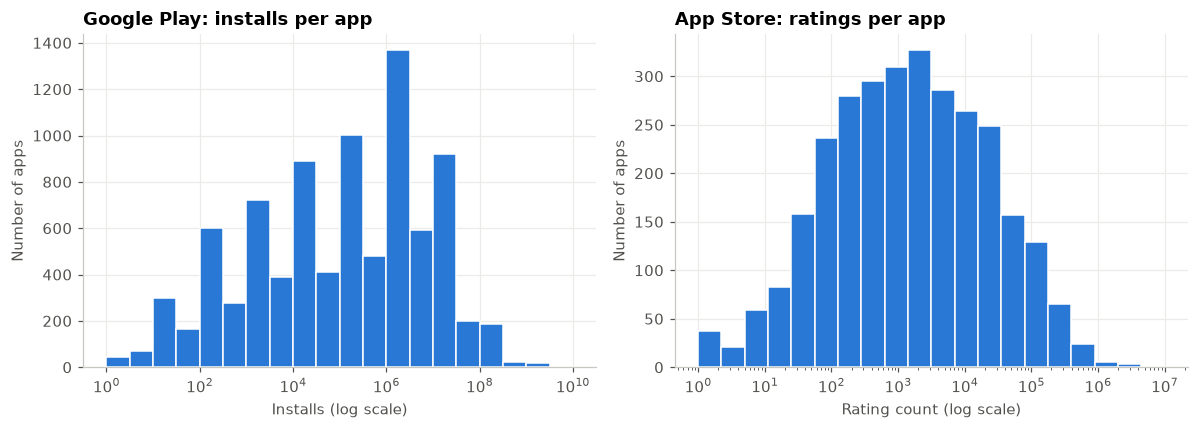

In [22]:
# Keep only positive values so they fit a log scale
google_installs = [clean_installs(row[google_header.index('Installs')]) for row in free_apps_google]
google_installs = [v for v in google_installs if v > 0]
apple_ratings = [int(row[apple_header.index('rating_count_tot')]) for row in free_apps_apple]
apple_ratings = [v for v in apple_ratings if v > 0]

# Two side-by-side charts, one per store
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Log-spaced bins for Google installs
ax1.hist(google_installs, bins=np.logspace(0, 10, 21), color=HIGHLIGHT, edgecolor='white', linewidth=1)
ax1.set_xscale('log')
ax1.set_title('Google Play: installs per app')
ax1.set_xlabel('Installs (log scale)')
ax1.set_ylabel('Number of apps')

# Log-spaced bins for Apple rating counts
ax2.hist(apple_ratings, bins=np.logspace(0, 7, 21), color=HIGHLIGHT, edgecolor='white', linewidth=1)
ax2.set_xscale('log')
ax2.set_title('App Store: ratings per app')
ax2.set_xlabel('Rating count (log scale)')
ax2.set_ylabel('Number of apps')

plt.tight_layout()
plt.show()


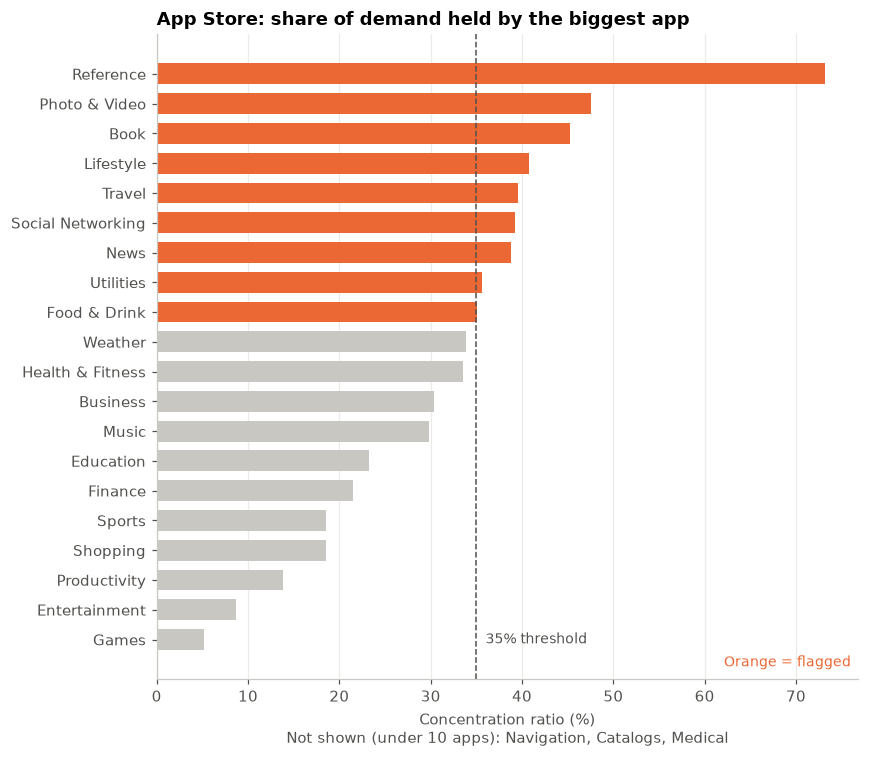

In [23]:
# Combine trusted and flagged pairs, lowest first so the highest sits at the top
all_apple_ratios = sorted(trusted_apple + flagged_apple, key=lambda pair: pair[1])
genres = [genre for genre, ratio in all_apple_ratios]
ratios = [ratio * 100 for genre, ratio in all_apple_ratios]
# Orange for flagged genres, grey for trusted
flagged_names = [genre for genre, ratio in flagged_apple]
colours = [FLAGGED if genre in flagged_names else NEUTRAL for genre in genres]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(genres, ratios, color=colours, height=0.7)
# Dashed line at the threshold
ax.axvline(CONCENTRATION_THRESHOLD * 100, color=TEXT, linestyle='--', linewidth=1)
ax.text(CONCENTRATION_THRESHOLD * 100 + 1, 0, f'{CONCENTRATION_THRESHOLD:.0%} threshold', color=TEXT, fontsize=9, va='center')
ax.set_title('App Store: share of demand held by the biggest app')
# Axis label also names the genres left out for being too small
small_names = ', '.join(genre for genre, count in too_small_apple)
ax.set_xlabel(f'Concentration ratio (%)\nNot shown (under {MIN_APPS} apps): {small_names}')
ax.grid(axis='y', visible=False)
# Direct label for the flagged group
ax.text(0.99, 0.02, 'Orange = flagged', transform=ax.transAxes, ha='right', color=FLAGGED, fontsize=9)

plt.tight_layout()
plt.show()


## Outlier check: concentration by genre

### Why this step exists
Average installs (or ratings) per genre can be misleading: one huge app can drag a whole genre's average up and make it look like a gap in the market when it isn't. Earlier I handled this by hand-removing Facebook and WhatsApp. This step replaces that with an **automated check that works on any genre**, so I'm not relying on spotting outliers myself. To test that, the pipeline runs on `free_apps_apple`, with Facebook and WhatsApp put back in.

### How it works
1. **`filtering_process_by_genre(dataset, genre_index, value_index)`**
   Goes through every app and groups its popularity value by genre, returning a dict: `{genre: [value, value, ...]}`.
   - Google Play: grouped by `Genres`, value = `Installs` (cleaned with `clean_installs`)
   - App Store: grouped by `prime_genre`, value = `rating_count_tot` (the App Store has no install counts, so the number of ratings is used instead)

2. **`concentration_ratio(values)`**
   For one genre's list of values: **biggest single app ÷ genre total**.
   - 0.05 → the biggest app holds 5% of the genre's popularity (spread out, healthy)
   - 0.90 → one app holds 90% (the genre's average is really just that app)

3. **`hhi(values)`**, the Herfindahl-Hirschman Index
   A second measure of concentration: square every app's % share of the genre and add them up. It runs from close to 0 (demand spread over many apps) to 10,000 (one app holds everything). The concentration ratio only looks at the biggest app, but the HHI counts all of them, so it also notices when two or three apps share most of the demand.

4. **`split_genres(grouped, threshold, min_apps)`**
   Sorts each genre into one of three groups:
   - **Too small to judge:** fewer than **10 apps** (`MIN_APPS`), stored as `(genre, app count)` pairs
   - **Trusted:** ratio **< 35%** (`CONCENTRATION_THRESHOLD`), so no single app dominates
   - **Flagged:** ratio **≥ 35%**, so one app accounts for more than a third of the genre

   Flagged genres are **marked, not deleted**, so they can still be shown in the final results with a warning. Too-small genres are left out of the scoring.

5. **Borderline label**
   A trusted genre with an HHI of **1,800 or more** (`HHI_THRESHOLD`) is labelled `borderline (HHI)`. The ratio still decides trusted vs flagged. The HHI is a second opinion that shows where the two measures disagree.

6. **Output:** each group is printed highest ratio first, with each genre's HHI.

### Why these settings
- **A minimum of 10 apps.** With *n* apps in a genre, the lowest possible concentration ratio is 1 ÷ n, reached when every app is exactly equal. A genre with 2 apps is at least 50% concentrated, so it would always be flagged whatever its data says, and the HHI has the same floor (1 ÷ n × 10,000). At 10 apps the floors are 10% and 1,000, which leaves real room to pass or fail, and the quartiles in Step 4 have enough values to mean something. The same minimum is used for both stores, because it protects the reliability of each genre's own numbers, and that depends on the number of apps in the genre, not in the whole store.
- **A 35% concentration threshold.** This borrows from competition law, where regulators judge dominance by the largest company's share of a market. The European Commission's 2009 guidance on abuse of dominance says dominance is not likely below a 40% market share, and EU case law (*AKZO*, 1991) presumes dominance above 50%. A 35% line is slightly stricter than the Commission's 40% level, which suits an analysis that wants to avoid genres led by one app.
- **An HHI line of 1,800.** The US Department of Justice and Federal Trade Commission's 2023 Merger Guidelines treat markets with an HHI above 1,800 as highly concentrated.
- All three are still judgement calls. The **sensitivity check** before the conclusion shows how the ranking changes when they are varied.

### Findings

**App Store**
- **Too small to judge (3):** Catalogs (4 apps), Navigation (5), Medical (6)
- **Flagged (9):** Reference (73.1%), Photo & Video (47.5%), Book (45.3%), Lifestyle (40.8%), Travel (39.5%), Social Networking (39.2%), News (38.8%), Utilities (35.6%), Food & Drink (35.1%)
- **Social Networking is flagged automatically (39.2%).** Facebook is in this genre, so the pipeline catches the outlier I had removed by hand.
- **Trusted (11), highest ratio first:** Weather (33.9%), Health & Fitness (33.5%), Business (30.4%), Music (29.8%), Education (23.3%), Finance (21.5%), Sports (18.5%), Shopping (18.5%), Productivity (13.8%), Entertainment (8.7%), Games (5.2%)
- **Key insight:** none of the **top 3 genres in the original opportunity table** survive. Reference and Book are flagged, because one app holds much of their demand, and Navigation (the original 1st) has only 5 free apps, too few to judge. Their high scores don't show a real gap in the market.
- **Weather is borderline.** It is the strongest trusted genre from the original table (score 62,548), but its ratio of 33.9% sits just under the 35% threshold and its HHI (1,807) is just over the 1,800 line. Health & Fitness is the only other borderline App Store genre (HHI 1,926).
- **Games has the lowest ratio (5.2%) and HHI (103)**: popularity is spread across many apps, which fits it being the most crowded genre.

**Google Play**
- **56 genres are too small to judge.** Almost all are narrow combined genres such as `Comics;Creativity` or `Trivia;Education`, and 25 of them contain a single app. Before the minimum was added, these were flagged at 100%, because one app is always 100% of its own genre.
- **15 genres are flagged**, led by Trivia (77.8%), `Puzzle;Brain Games` (71.8%) and `Education;Education` (70.1%). Large standalone genres are flagged too, such as Health & Fitness (43.9%), News & Magazines (42.3%) and Books & Reference (60.0%).
- **41 genres are trusted**, topping out around **35%** (e.g. Travel & Local 34.6%). Weather is trusted on Google Play too, with a low ratio (13.9%) and HHI (865).
- **6 trusted genres are borderline:** Music, `Arcade;Action & Adventure`, Travel & Local, Board, Events and Word.

### Limitations
- **Using `Genres` instead of `Category`** for Google Play creates many tiny sub-genres. The minimum sets the smallest aside, but some combined genres with 10 to 20 apps remain.
- **Google's install numbers are grouped into bands** (e.g. 1,000,000+), not exact counts, so ratios and HHI values are approximate.
- **The thresholds are judgement calls** backed by precedent, not statistical rules. See the sensitivity check.
- **The HHI line was designed for markets of companies**, not app genres, so 1,800 is a borrowed reference point rather than a rule.

In [24]:
# Quartile function from the standard library
from statistics import quantiles

def iqr_filter(values):
    # Remove high outliers (above Q3 + 1.5 x IQR) from one genre's values

    # Lists under 2 values can't have quartiles
    if len(values) < 2:
        return values

    # Q1, median, Q3 ('inclusive' explained in the Markdown below)
    quantile_variable = quantiles(values, n=4, method='inclusive')
    Q1 = quantile_variable[0]
    Q3 = quantile_variable[2]
    # Spread of the middle 50% and the upper cut-off
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    # Keep values at or below the cut-off
    filtered_values = []
    for value in values:
        if value <= upper_bound:
            filtered_values.append(value)
    return filtered_values

# Step 4: IQR-filter trusted Google genres
cleaned_google = {}
for genre, ratio in trusted_google:
    cleaned_google[genre] = iqr_filter(google_filtered[genre])

# Same for trusted App Store genres
cleaned_apple = {}
for genre, ratio in trusted_apple:
    cleaned_apple[genre] = iqr_filter(apple_filter[genre])

# Check: each pair of numbers should match
print(len(cleaned_google), len(trusted_google))
print(len(cleaned_apple), len(trusted_apple))

41 41
11 11


/var/folders/hh/lkvkb3qx2lxch4pt4lhhz39r0000gn/T/ipykernel_52816/1388858855.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(box_data, vert=False, whis=1.5, widths=0.5,


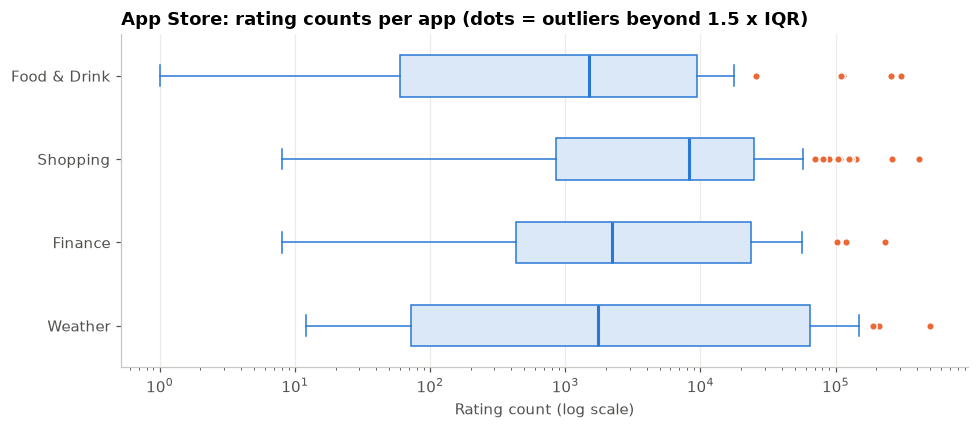

In [25]:
# Genres to compare
box_genres = ['Weather', 'Finance', 'Shopping', 'Food & Drink']
# Raw rating counts per genre, zeros removed for the log scale
box_data = [[v for v in apple_filter[genre] if v > 0] for genre in box_genres]

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(box_data, vert=False, whis=1.5, widths=0.5,
           patch_artist=True,
           boxprops={'facecolor': '#dbe8f8', 'edgecolor': HIGHLIGHT},
           medianprops={'color': HIGHLIGHT, 'linewidth': 2},
           whiskerprops={'color': HIGHLIGHT},
           capprops={'color': HIGHLIGHT},
           flierprops={'marker': 'o', 'markersize': 5, 'markerfacecolor': FLAGGED, 'markeredgecolor': 'white'})
ax.set_yticks(range(1, len(box_genres) + 1))
ax.set_yticklabels(box_genres)
ax.set_xscale('log')
ax.set_title('App Store: rating counts per app (dots = outliers beyond 1.5 x IQR)')
ax.set_xlabel('Rating count (log scale)')
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()


## Step 4: IQR outlier filter (trusted genres only)

Even after the concentration check, trusted genres can still contain a few unusually large apps that inflate the genre average. The IQR filter removes these so that each average better reflects a **typical** app in the genre.

### Why only trusted genres?
- In a flagged genre, the dominant app *is* the finding. Filtering it out would hide the very reason the genre was flagged.
- Flagged genres are therefore kept as they are and **marked** in the final output, rather than being "cleaned" into looking normal.

### How `iqr_filter` works
1. **Quartiles:** `statistics.quantiles(values, n=4)` always returns three cut points: `[Q1, median, Q3]`.
2. **Spread:** `IQR = Q3 − Q1`, the range covered by the middle 50% of apps.
3. **Cut-off:** `upper bound = Q3 + 1.5 × IQR`. Any value above this is treated as an outlier and dropped.
4. **High outliers only:** the concern is very large apps inflating the average, so low values are left in.
5. **Small genres:** lists with fewer than 2 values are returned unchanged, since quartiles cannot be calculated for them.

### Decision: `method='inclusive'`
- With the default (`exclusive`) method, the test list `[10, 12, 11, 13, 500]` **kept** the 500. The outlier itself pulled Q3 up to about 256, which made the cut-off far too high.
- `inclusive` treats each genre's list as the complete dataset, which is accurate here. This gives Q3 = 13 and a cut-off of 16, so the 500 is correctly removed.
- **Takeaway:** the method used to calculate quartiles matters, especially for small groups.

### Result
Each trusted genre now has a cleaned list of values: **41** Google Play genres (`cleaned_google`) and **11** App Store genres (`cleaned_apple`).

### Limitations
- The **1.5 × IQR rule is a convention**, not a statistical law.
- **Google Play installs are grouped into bands** (e.g. 1,000+, 10,000+), so many apps share identical values, and the filter may remove an entire band at once.
- In **small genres**, quartiles are unstable, so the filter may remove too little or too much.

In [26]:
# Dicts for Google averages
avg_google = {}
avg_google_flagged = {}

# Dicts for Apple averages
avg_apple = {}
avg_apple_flagged = {}

# Trusted Google averages
for genre, values in cleaned_google.items():
    avg_google[genre] = sum(values) / len(values)

# Flagged Google averages
for genre, ratio in flagged_google:
    genres_raw_install = google_filtered[genre]
    avg_google_flagged[genre] = sum(genres_raw_install) / len(genres_raw_install)

# Trusted Apple averages
for genre, values in cleaned_apple.items():
    avg_apple[genre] = sum(values) / len(values)

# Flagged Apple averages
for genre, ratio in flagged_apple:
    apple_genre_raw_install = apple_filter[genre]
    avg_apple_flagged[genre] = sum(apple_genre_raw_install) / len(apple_genre_raw_install)

# Print all four results, highest average first
print('Google Play: cleaned averages (trusted genres)')
display_tables_installs(avg_google)
print('\n')
print('Google Play: raw averages (flagged genres)')
display_tables_installs(avg_google_flagged)
print('\n')
print('App Store: cleaned averages (trusted genres)')
display_tables_installs(avg_apple)
print('\n')
print('App Store: raw averages (flagged genres)')
display_tables_installs(avg_apple_flagged)


Google Play: cleaned averages (trusted genres)
Casual;Pretend Play: 4,805,000
Arcade: 3,778,804
Action: 3,522,168
Photography: 3,422,793
Arcade;Action & Adventure: 3,190,909
Strategy: 2,959,887
Word: 2,958,628
Shopping: 2,920,695
Role Playing: 2,828,995
Racing: 2,818,828
Card: 2,631,244
Casual: 2,594,103
Puzzle: 2,587,373
Weather: 2,456,746
Communication: 2,368,038
Video Players & Editors: 2,206,879
Simulation: 2,153,765
Social: 2,045,845
Travel & Local: 2,039,291
Sports: 1,938,979
Board: 1,832,681
Productivity: 1,747,668
Music: 1,358,607
Adventure: 541,492
House & Home: 426,706
Educational;Education: 400,000
Food & Drink: 380,858
Maps & Navigation: 301,183
Comics: 296,914
Finance: 241,670
Personalization: 238,920
Auto & Vehicles: 236,580
Tools: 220,305
Dating: 206,065
Entertainment: 205,956
Lifestyle: 187,954
Libraries & Demo: 32,158
Events: 26,306
Education: 21,901
Medical: 20,287
Business: 11,880


Google Play: raw averages (flagged genres)
Casual;Action & Adventure: 12,916,667
News

## Step 5: Average installs per genre

This step in the analysis reduces each genre's list of values to a single figure, its **average**.

### Trusted vs flagged genres
- **Trusted genres** are averaged from their **cleaned** values (`cleaned_google` / `cleaned_apple`). With outliers removed in Step 4, the average reflects a *typical* app in the genre rather than being inflated by a small number of very large apps.
- **Flagged genres** are averaged from their **raw** values (`google_filtered` / `apple_filter`). Their dominant app is the reason they were flagged, so it is deliberately kept in. These genres are marked with a warning in the final output rather than being presented as reliable.

### Method
1. Loop through each genre using `.items()`, which returns the genre name and its list of values together on each pass.
2. Calculate the average as `sum(values) / len(values)`.
3. Store the result under the genre name in a dictionary:
   - `avg_google` / `avg_apple`: trusted genres
   - `avg_google_flagged` / `avg_apple_flagged`: flagged genres

### Result
- **Google Play:** 41 trusted + 15 flagged = 56 genres with an average (the 56 too-small genres are not scored)
- **App Store:** 11 trusted + 9 flagged = 20 genres with an average (the 3 too-small genres are not scored)

### Observations
- **Weather** has the highest cleaned average of any trusted App Store genre (**12,572 ratings** per app), ahead of Productivity (11,810) and Shopping (10,526).
- **Food & Drink** is now flagged (35.1%). Its raw average of about 33,334 ratings is driven by one dominant app, so it is no longer treated as a reliable candidate.

### Limitations
- **Google Play installs are grouped into bands** (e.g. 1,000+, 10,000+), so each average is an approximation rather than an exact figure.
- **App Store ratings are used in place of installs.** Rating counts measure how engaged users are, not how many times an app was downloaded.
- **Averages are sensitive to genre size.** A genre with only a few apps can have an unstable average.

In [27]:
# Divide each genre's average demand by its frequency %
def opportunity_score(average_dict, frequency_dict , result_dict):
    # Loop over each genre and its average demand
    for genre, demand in average_dict.items():
        # Store the opportunity score under the genre name 
        result_dict[genre] = average_dict[genre] / frequency_dict[genre]
    # Return the full dict of genre scores
    return result_dict

# Empty dicts to hold trusted genre scores
opportunity_google = {}
opportunity_apple = {}

# Empty dicts to hold flagged genre scores
flagged_opportunity_google = {}
flagged_opportunity_apple = {}

# Score trusted Google genres
google_opportunity_score = opportunity_score(avg_google, frequency_table, opportunity_google)
# Sort trusted Google scores, highest first
sorted_google_opportunity = sorted(google_opportunity_score.items(), key=lambda pair: pair[1], reverse=True)
# Score trusted App Store genres
apple_opportunity_score = opportunity_score(avg_apple, frequency_table_apple, opportunity_apple)
# Sort trusted App Store scores, highest first
sorted_apple_opportunity = sorted(apple_opportunity_score.items(), key=lambda pair: pair[1], reverse=True)

# Score flagged genres for both stores
flagged_google_opportunity_score = opportunity_score(avg_google_flagged, frequency_table, flagged_opportunity_google)
flagged_apple_opportunity_score = opportunity_score(avg_apple_flagged, frequency_table_apple, flagged_opportunity_apple)
# Sort flagged scores, highest first
sorted_flagged_opportunity = sorted(flagged_google_opportunity_score.items(), key=lambda pair: pair[1], reverse=True)
sorted_flagged_apple_opportunity = sorted(flagged_apple_opportunity_score.items(), key=lambda pair: pair[1], reverse=True)

# Check: number of genres scored in each list (full rankings in step 7)
print('Google Play: trusted', len(sorted_google_opportunity), '| flagged', len(sorted_flagged_opportunity))
print('App Store: trusted', len(sorted_apple_opportunity), '| flagged', len(sorted_flagged_apple_opportunity))


Google Play: trusted 41 | flagged 15
App Store: trusted 11 | flagged 9


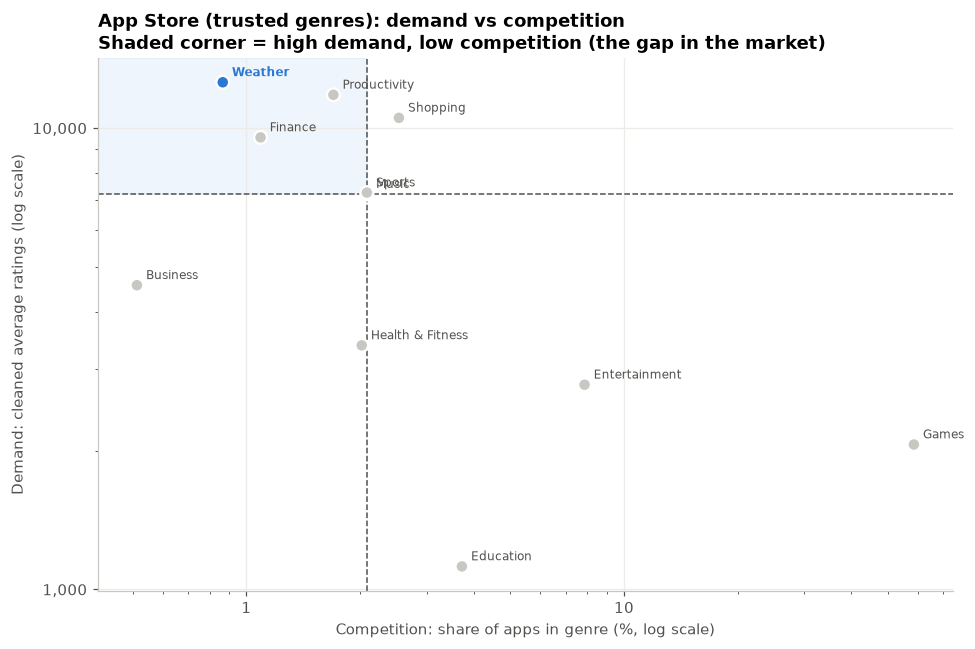

In [28]:
# Competition (x) and demand (y) for each trusted genre
quad_genres = list(avg_apple.keys())
competition = [frequency_table_apple[genre] for genre in quad_genres]
demand = [avg_apple[genre] for genre in quad_genres]
# Medians split the chart into four quadrants
x_mid = np.median(competition)
y_mid = np.median(demand)

fig, ax = plt.subplots(figsize=(9, 6))
# Highlight Weather, grey for the rest
colours = [HIGHLIGHT if genre == 'Weather' else NEUTRAL for genre in quad_genres]
ax.scatter(competition, demand, s=70, color=colours, edgecolor='white', linewidth=1.5, zorder=3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(x_mid, color=TEXT, linestyle='--', linewidth=1)
ax.axhline(y_mid, color=TEXT, linestyle='--', linewidth=1)
# Label every genre next to its dot
for genre, x, y in zip(quad_genres, competition, demand):
    ax.annotate(genre, (x, y), xytext=(6, 4), textcoords='offset points', fontsize=8,
                color=HIGHLIGHT if genre == 'Weather' else TEXT,
                fontweight='bold' if genre == 'Weather' else 'normal')
# Shade the gap-in-the-market corner (top left)
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.add_patch(plt.Rectangle((x_min, y_mid), x_mid - x_min, y_max - y_mid, color=HIGHLIGHT, alpha=0.07, zorder=0))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
# Plain numbers instead of scientific notation on log axes
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value:g}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value:,.0f}'))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_title('App Store (trusted genres): demand vs competition\nShaded corner = high demand, low competition (the gap in the market)')
ax.set_xlabel('Competition: share of apps in genre (%, log scale)')
ax.set_ylabel('Demand: cleaned average ratings (log scale)')

plt.tight_layout()
plt.show()


## Step 6: Opportunity Score

### What this step does
This step combines **demand** and **competition** into a single number for each genre:

**Opportunity score = average demand ÷ frequency %**

- **Average demand** comes from Step 5: average installs per app (Google Play) or average rating count per app (App Store).
- **Frequency %** is the share of apps in the dataset that belong to that genre. It stands in for competition.

A high score means apps in that genre get a lot of users while relatively few apps compete for them, which is what we mean by a gap in the market.

A ratio was chosen instead of multiplication. Multiplying demand by frequency would reward crowded genres, which is the opposite of what we want.

### How it works
- A reusable function, `opportunity_score()`, loops over a genre → average dictionary, divides each average by that genre's frequency %, and stores the result under the genre name.
- The function runs separately on **trusted** genres (IQR-cleaned averages) and **flagged** genres (raw averages). This keeps the reliability split from Steps 3–5.
- Each result is sorted from highest to lowest score using `sorted(..., key=lambda pair: pair[1], reverse=True)`.

### Findings: Google Play (trusted)
- The top two are still **combined sub-genres**: `Arcade;Action & Adventure` (about 25.1M, 11 apps) and `Casual;Pretend Play` (about 19.8M, 21 apps). The minimum size removed the one-app sub-genres that used to lead, but these two just clear it, and their small share of apps still inflates their scores.
- Among standalone genres, **Word** (about 11.2M), **Music** (about 6.9M), **Card** (about 5.7M), **Board** (about 4.8M), **Strategy** (about 3.2M) and **Weather** (about 3.1M) score highest.
- **Weather ranks 8th of 41**, the highest non-game standalone genre after Music (which is borderline, with an HHI of 2,670).
- **Finance** (33rd, about 66,300) and **Business** (41st, last) score poorly on Google Play.

### Findings: App Store (trusted)
- Top trusted genres: **Weather** (14,514), **Business** (8,894) and **Finance** (8,753).
- **Weather is marked borderline:** its HHI (1,807) is just over the 1,800 line, even though its ratio passes.
- All scores are lower than in the original table because IQR filtering removed the very large apps that were inflating the averages.
- Compared with the original table:
  - **Weather** stays top among trusted genres (62,548 → 14,514)
  - **Finance** holds up well (29,211 → 8,753)
  - **Music** collapses from 27,894 to 3,450 (7th), so a few big apps drove its original score
  - **Shopping** drops from 11,264 to 4,153 (5th)
  - **Food & Drink** is now flagged, so it no longer counts as a trusted candidate
- **Weather is the only genre in the App Store top 5 that also ranks in the top third on Google Play**, which makes it the strongest candidate for a cross-platform app.

### Flagged genres
Flagged genres were scored but kept separate. Their averages come from raw values and are driven by one dominant app, so a high score here does not show broad demand. On the App Store, **Reference and Book**, 2nd and 3rd in the original opportunity table, fall into this group, along with Food & Drink and Social Networking. **Navigation**, the original 1st, has only 5 free apps, so it is set aside as too small to judge.

### Things to keep in mind
- **Scores can't be compared across stores.** Google scores are based on installs (millions) and App Store scores on rating counts (thousands). Compare a genre's **rank** in each store, not its raw score.
- **Very small genres get inflated scores.** When the frequency % is close to zero, the score shoots up. The 10-app minimum removes the worst cases, but genres just above it can still be inflated.

In [29]:
# Print a titled, numbered ranking of genres and their opportunity scores
def display_opportunity(sorted_score, title, borderline=()):
    # Print the table heading
    print(title)
    # Width of the longest genre name, so the columns line up
    name_width = max((len(genre) for genre, score in sorted_score), default=0)
    # Loop over each genre with a rank starting at 1
    for rank, (genre, score) in enumerate(sorted_score, 1):
        # Mark genres whose HHI is over the line
        note = '  borderline (HHI)' if genre in borderline else ''
        # Rank and score right-aligned, genre left-aligned, score with commas
        print(f'{rank:>3}. {genre:<{name_width}}  {score:>14,.0f}{note}')
    # Print blank line between tables
    print()

# Trusted rankings for both stores
display_opportunity(sorted_google_opportunity, 'Trusted Google Play genres', borderline_google)
display_opportunity(sorted_apple_opportunity, 'Trusted App Store genres', borderline_apple)

# Flagged rankings for both stores
display_opportunity(sorted_flagged_opportunity, 'Flagged Google Play genres')
display_opportunity(sorted_flagged_apple_opportunity, 'Flagged App Store genres')


Trusted Google Play genres
  1. Arcade;Action & Adventure      25,147,265  borderline (HHI)
  2. Casual;Pretend Play            19,835,498
  3. Word                           11,151,453  borderline (HHI)
  4. Music                           6,928,097  borderline (HHI)
  5. Card                            5,702,563
  6. Board                           4,814,397  borderline (HHI)
  7. Strategy                        3,167,810
  8. Weather                         3,086,599
  9. Role Playing                    2,954,766
 10. Racing                          2,776,866
 11. Puzzle                          2,312,365
 12. Arcade                          2,060,280
 13. Casual                          1,450,857
 14. Shopping                        1,285,254
 15. Video Players & Editors         1,250,420
 16. Photography                     1,145,644
 17. Action                          1,118,450
 18. Simulation                      1,031,546
 19. Educational;Education             990,744
 20. Tra

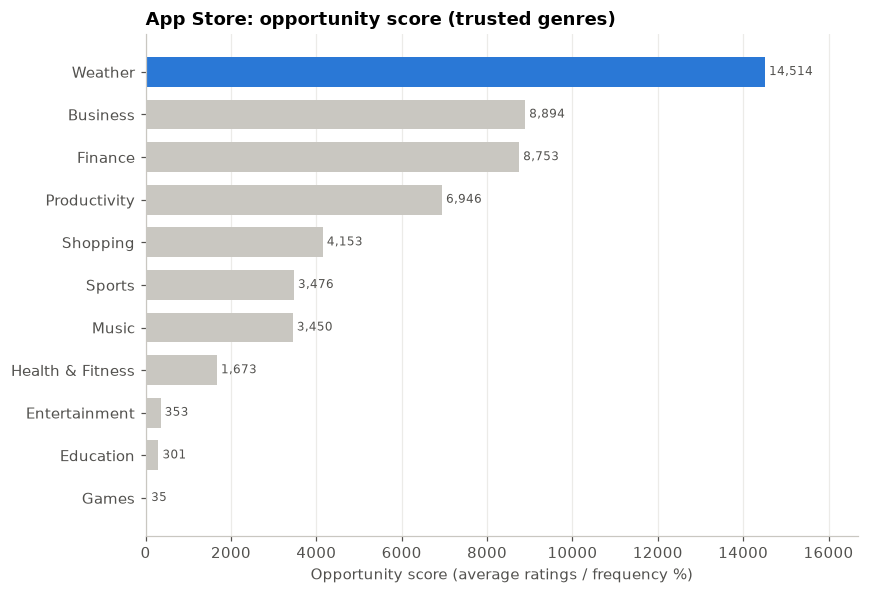

In [30]:
# Trusted App Store scores, lowest first so the top sits at the top
ranked = sorted(opportunity_apple.items(), key=lambda pair: pair[1])
genres = [genre for genre, score in ranked]
scores = [score for genre, score in ranked]
colours = [HIGHLIGHT if genre == 'Weather' else NEUTRAL for genre in genres]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(genres, scores, color=colours, height=0.7)
# Value label at the end of each bar
for bar, score in zip(bars, scores):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f' {score:,.0f}', va='center', fontsize=8, color=TEXT)
ax.set_title('App Store: opportunity score (trusted genres)')
ax.set_xlabel('Opportunity score (average ratings / frequency %)')
ax.grid(axis='y', visible=False)
ax.set_xlim(0, max(scores) * 1.15)

plt.tight_layout()
plt.show()


## Step 7: Ranked Output

### What this step does
This step turns the sorted opportunity scores from Step 6 into readable, ranked tables, one for each store and reliability group:

- Trusted Google Play genres
- Trusted App Store genres
- Flagged Google Play genres
- Flagged App Store genres

### How it works
- A reusable function, `display_opportunity()`, takes a sorted list of `(genre, score)` pairs and a title. It prints the title as a heading, then one row per genre.
- Genres passed in the optional `borderline` input are marked `borderline (HHI)`.
- `enumerate(..., 1)` adds a rank to each row, starting at 1.
- The columns are lined up with f-string alignment: `{rank:>3}` right-aligns the rank, `{genre:<{name_width}}` pads each name to the length of the longest genre, and `{score:>14,.0f}` right-aligns the score with thousands commas and no decimals.
- Writing one function and calling it four times avoids repeating the same loop for each table.
- Trusted and flagged genres are displayed **separately** so the reliability split from Step 3 stays visible. Flagged genres are shown, not dropped, so the reader can see which high scores are driven by a single dominant app.

### Checkpoints
- 41 trusted Google Play genres and 11 trusted App Store genres, matching the Step 4 counts.
- The flagged App Store table is led by Reference and Book, 2nd and 3rd in the original opportunity table. Navigation (1st) is too small to judge, so it isn't ranked.


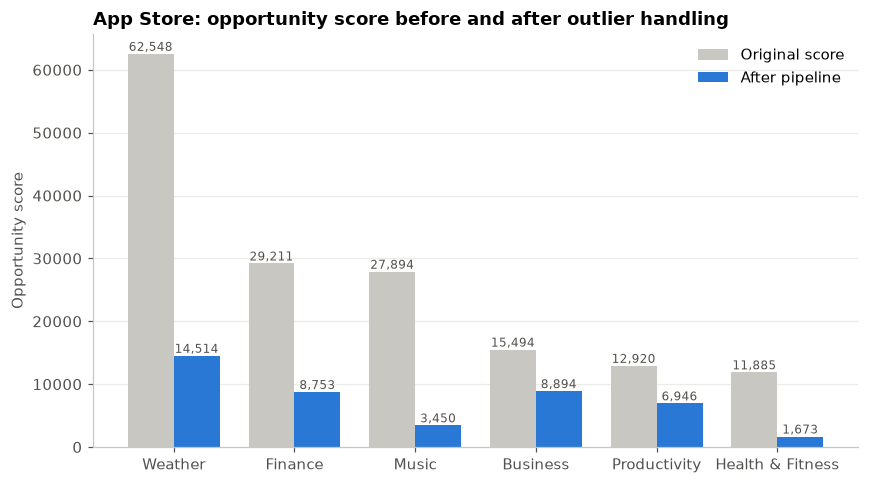

In [31]:
# Trusted genres with the 6 highest original scores
compare_genres = sorted(opportunity_apple, key=lambda genre: original_opportunity[genre], reverse=True)[:6]
# Original score vs score after the pipeline
before = [original_opportunity[genre] for genre in compare_genres]
after = [opportunity_apple[genre] for genre in compare_genres]

# Positions for side-by-side bars
positions = np.arange(len(compare_genres))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(positions - width / 2, before, width, color=NEUTRAL, label='Original score')
ax.bar(positions + width / 2, after, width, color=HIGHLIGHT, label='After pipeline')
# Value label above each bar
for x, value in zip(positions - width / 2, before):
    ax.text(x, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=8, color=TEXT)
for x, value in zip(positions + width / 2, after):
    ax.text(x, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=8, color=TEXT)
ax.set_xticks(positions)
ax.set_xticklabels(compare_genres)
ax.set_title('App Store: opportunity score before and after outlier handling')
ax.set_ylabel('Opportunity score')
ax.grid(axis='x', visible=False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


## Sensitivity check: how much do the settings matter?

### Why this step exists
The 10-app minimum, the 35% threshold and the 1,800 HHI line are all judgement calls. Changing them can't make the analysis "correct", but it shows whether the recommendation depends on one particular choice. If Weather stays near the top across reasonable settings, the result is robust. If it only wins under one setting, the reader should know.

### How it works
- `trusted_ranking()` runs Steps 3 to 6 again for one set of settings, reusing `split_genres`, `iqr_filter` and `opportunity_score`, and returns the trusted genres ranked by opportunity score.
- The `hhi_strict` option also drops trusted genres with an HHI of 1,800 or more. It tests what would happen if the HHI decided, instead of only labelling.
- The loop runs every setting in `settings` and prints Weather's rank on each store and the App Store's top genre.

### Findings
| Setting | Weather: App Store | Weather: Google Play | App Store #1 |
|---|---|---|---|
| Ratio 30% | not trusted | 5 of 35 | Finance |
| **Ratio 35% (used)** | **1 of 11** | **8 of 41** | **Weather** |
| Ratio 40% | 1 of 16 | 8 of 44 | Weather |
| Minimum 5 apps | 1 of 11 | 13 of 46 | Weather |
| Minimum 20 apps | 1 of 10 | 6 of 39 | Weather |
| Minimum 30 apps | not trusted | 4 of 37 | Finance |
| HHI strict (1,800) | not trusted | 4 of 35 | Business |

- **Google Play is robust.** Weather ranks between 4th and 13th under every setting. Its low ratio (13.9%) and HHI (865) mean it is never flagged.
- **The App Store result is fragile.** Weather is 1st in four of the seven settings, but it drops out under a 30% threshold (its ratio is 33.9%), a 30-app minimum (it has 27 apps) and the strict HHI rule (its HHI is 1,807).
- **No other genre replaces it consistently.** When Weather drops out, the App Store leader switches between Finance and Business, and both rank near the bottom on Google Play (33rd and 41st of 41).
- **Takeaway:** Weather is the strongest candidate under most reasonable settings, but its App Store lead depends on how strictly concentration is judged. That's why the recommendation is to test it first, not to treat it as certain.

In [32]:
# Trusted genres ranked by opportunity score for one set of pipeline settings
def trusted_ranking(grouped, frequency, threshold, min_apps, hhi_strict=False):
    trusted, flagged, too_small = split_genres(grouped, threshold, min_apps)
    averages = {}
    for genre, ratio in trusted:
        # HHI-strict runs also drop genres over the HHI line
        if hhi_strict and hhi(grouped[genre]) >= HHI_THRESHOLD:
            continue
        # Same steps as the pipeline: IQR filter, then average
        values = iqr_filter(grouped[genre])
        averages[genre] = sum(values) / len(values)
    scores = opportunity_score(averages, frequency, {})
    return sorted(scores, key=scores.get, reverse=True)

# Rank of a genre as 'x of n', or why it has no rank
def rank_label(ranking, genre):
    if genre in ranking:
        return f'{ranking.index(genre) + 1} of {len(ranking)}'
    return 'not trusted'

# Settings to test: (label, threshold, minimum apps, HHI strict)
settings = [
    ('Ratio 30%', 0.30, MIN_APPS, False),
    ('Ratio 35% (used)', 0.35, MIN_APPS, False),
    ('Ratio 40%', 0.40, MIN_APPS, False),
    ('Minimum 5 apps', CONCENTRATION_THRESHOLD, 5, False),
    ('Minimum 20 apps', CONCENTRATION_THRESHOLD, 20, False),
    ('Minimum 30 apps', CONCENTRATION_THRESHOLD, 30, False),
    ('HHI strict (1,800)', CONCENTRATION_THRESHOLD, MIN_APPS, True),
]

# One row per setting: Weather's rank on each store and the App Store leader
print(f"{'Setting':<20} {'Weather: App Store':>20} {'Weather: Google Play':>22}   App Store #1")
for label, threshold, min_apps, hhi_strict in settings:
    apple_rank = trusted_ranking(apple_filter, frequency_table_apple, threshold, min_apps, hhi_strict)
    google_rank = trusted_ranking(google_filtered, frequency_table, threshold, min_apps, hhi_strict)
    print(f'{label:<20} {rank_label(apple_rank, "Weather"):>20} {rank_label(google_rank, "Weather"):>22}   {apple_rank[0]}')


Setting                Weather: App Store   Weather: Google Play   App Store #1
Ratio 30%                     not trusted                5 of 35   Finance
Ratio 35% (used)                  1 of 11                8 of 41   Weather
Ratio 40%                         1 of 16                8 of 44   Weather
Minimum 5 apps                    1 of 11               13 of 46   Weather
Minimum 20 apps                   1 of 10                6 of 39   Weather
Minimum 30 apps               not trusted                4 of 37   Finance
HHI strict (1,800)            not trusted                4 of 35   Business


## Conclusion: Recommended App Profile

### Recommendation: a free Weather app
**Weather** is the best genre to test first. Once dominant apps and outliers are accounted for, it has the best combined ranking across the two stores: **1st of 11** trusted genres on the App Store and **8th of 41** on Google Play. The evidence is moderate rather than conclusive. The App Store result rests on only about 27 apps, and Weather is borderline on both concentration measures: its ratio (33.9%) sits just under the 35% threshold and its HHI (1,807) is just over the 1,800 line. The sensitivity check shows it stays 1st in four of the seven settings tested, but drops out under a 30% threshold, a 30-app minimum or the stricter HHI rule. Because the validation strategy starts with a minimal Android version, that first test also checks the store where Weather's case is weakest.

| | App Store (trusted) | Google Play (trusted) |
|---|---|---|
| Rank | **1st of 11** | 8th of 41 (6th among standalone genres) |
| Opportunity score | 14,514 | 3,086,599 |
| Share of free apps | 0.87% | 0.80% |
| Concentration ratio | 33.9% | 13.9% |
| HHI | 1,807 (borderline) | 865 |

- **App Store:** Weather has the highest cleaned average of any trusted genre (12,572 ratings per app) while fewer than 1% of free apps are Weather apps. It sits in the high-demand, low-competition corner of the quadrant chart.
- **Google Play:** Weather ranks 8th of 41 trusted genres. The genres above it are two combined sub-genres with inflated scores, four game genres and Music. Its low concentration ratio (13.9%) and HHI (865) show demand is spread across many apps.

### Why not the other candidates?
- **Navigation, Reference, Book:** top of the original App Store table, but none survive the pipeline. Reference and Book are **flagged**, because a single dominant app drives their scores, and Navigation has only 5 free apps, too few to judge.
- **Business:** 2nd on the App Store (8,894) but last of 41 on Google Play.
- **Finance:** 3rd on the App Store (8,753) but only 33rd on Google Play.
- **Shopping:** the runner-up. It is solid on both stores (5th on the App Store, 14th on Google Play) but behind Weather on each.
- **Food & Drink:** strong in the original table but now flagged (35.1%).
- **Games:** several game genres score well on Google Play, but **Games ranks last** of the trusted App Store genres (35) because the market is saturated.

### Possible app profile
A free weather app with a clear angle that the big general forecast apps don't cover, for example **hyper-local forecasts with alerts for everyday plans** (commuting, running, events). Weather is checked daily, which suits an ad-funded model because users see ads often.

### Limitations
- **Close to both thresholds:** Weather's App Store concentration ratio (33.9%) is only just below the 35% cut-off and its HHI (1,807) is just above the 1,800 line, so a few apps hold much of the genre's ratings. A new app would need a clear point of difference.
- **Small sample:** only about 27 free English App Store apps are Weather apps, so its average rests on a small group.
- **Different demand measures:** Google Play uses installs and the App Store uses rating counts, so genres are compared across stores by **rank**, not by value.
- **Banded installs:** Google Play installs are grouped (1,000+, 10,000+, ...), so averages are approximate.
- **Small genres:** Google's combined sub-genres (e.g. `Casual;Pretend Play`) have few apps, which inflates their scores. The 10-app minimum sets the smallest aside, but some just above it still top the ranking. Grouping by `Category` instead of `Genres` would avoid them.
- **Judgement calls:** the 10-app minimum, the 35% threshold, the 1,800 HHI line and the 1.5 × IQR rule are conventions, not fixed rules. The sensitivity check shows the App Store ranking changes under stricter settings.